# Language identification using Naive Bayes and Maximum Entropy

Applies trained Naive Bayes and Maximum Entropy models to predict languages of new texts using TF-IDF character n-grams. Displays predictions and probabilities.

Naive Bayes is a probabilistic classifier that applies Bayes' theorem to predict the language of a text sample, assuming feature independence. For language detection, it uses features like character or word n-grams (e.g., "ing" for English, "ción" for Spanish) extracted from text, often via TF-IDF vectorization. The model calculates the probability of a text belonging to each language based on the likelihood of its features (e.g., P("ing" | English)) and prior language probabilities.

Maximum Entropy (MaxEnt), often implemented as multinomial logistic regression, models language detection as a classification task without assuming feature independence. It assigns weights to features (e.g., n-grams and TF-IDF scores) to maximize the entropy of the probability distribution, balancing fit to training data and generalization.


Naive Bayes is faster and easier to implement, making it ideal for quick prototyping or resource-constrained environments in language detection tasks. It performs well with character n-grams and large datasets but may underperform with short texts or correlated features due to its independence assumption. Maximum Entropy, conversely, offers higher accuracy by modeling feature interactions, excelling in scenarios with overlapping language patterns (e.g., Portuguese vs. Spanish) or diverse text lengths, but it’s slower and prone to overfitting without proper regularization.

Import libraries

In [1]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

Sample texts

In [2]:
texts = [
    "Hello world",
    "Hola mundo",
    "Bonjour le monde",
    "Hello everyone",
    "Adiós amigos",
    "Salut tout le monde",
    "Good morning",
    "Buenos días",
    "Bon matin",
    "How are you today?",
    "¿Cómo estás hoy?",
    "Comment vas-tu aujourd'hui ?",
    "Welcome to the party",
    "Bienvenidos a la fiesta",
    "Bienvenue à la fête",    
    "It's a beautiful day",
    "Es un día hermoso",
    "C'est une belle journée",
    "Let's go for a walk",
    "Vamos a pasear",
    "Allons nous promener",
    "Thank you very much",
    "Muchas gracias",
    "Merci beaucoup"
]

Labels

In [3]:
labels = [
    "English", "Spanish", "French",
    "English", "Spanish", "French",
    "English", "Spanish", "French",
    "English", "Spanish", "French",
    "English", "Spanish", "French",
    "English", "Spanish", "French",
    "English", "Spanish", "French",
    "English", "Spanish", "French"
]

Split data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

Initialize TF-IDF vectorizer

In [5]:
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Train and evaluate Naive Bayes

In [6]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_predictions)

Train and evaluate Maximum Entropy

In [7]:
maxent_model = LogisticRegression(max_iter=1000, random_state=42)
maxent_model.fit(X_train_tfidf, y_train)
maxent_predictions = maxent_model.predict(X_test_tfidf)
maxent_accuracy = accuracy_score(y_test, maxent_predictions)

Display accuracy

In [8]:
results_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'Maximum Entropy'],
    'Accuracy': [nb_accuracy, maxent_accuracy]
})
display(results_df)

,Model,Accuracy
0,Naive Bayes,0.8
1,Maximum Entropy,0.8


Plot confusion matrices

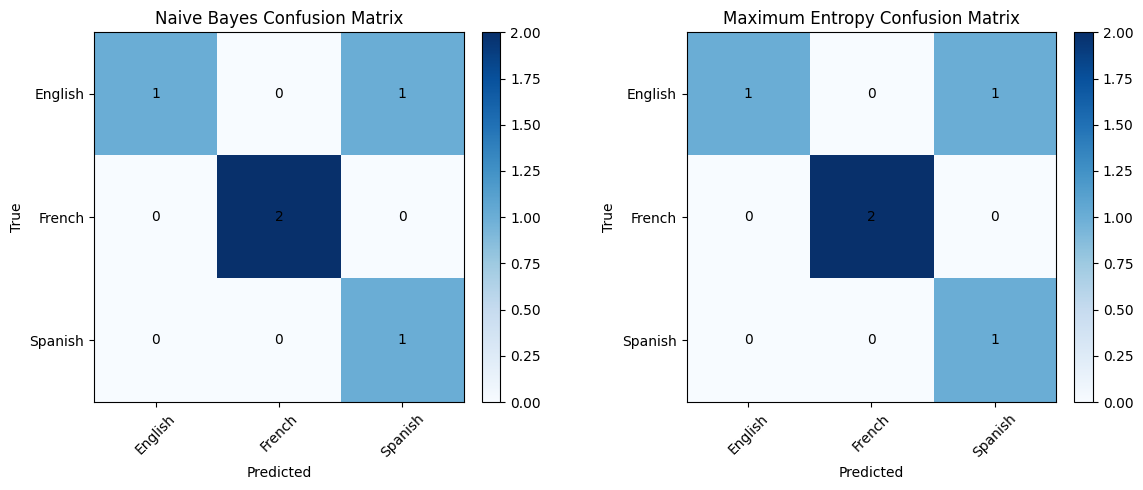

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
unique_labels = sorted(set(labels))
for i, (model_name, preds) in enumerate([('Naive Bayes', nb_predictions), ('Maximum Entropy', maxent_predictions)]):
    cm = confusion_matrix(y_test, preds, labels=unique_labels)
    im = axes[i].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xticks(np.arange(len(unique_labels)))
    axes[i].set_yticks(np.arange(len(unique_labels)))
    axes[i].set_xticklabels(unique_labels, rotation=45)
    axes[i].set_yticklabels(unique_labels)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    # Add text annotations
    for j in range(len(unique_labels)):
        for k in range(len(unique_labels)):
            text = axes[i].text(k, j, cm[j, k], ha='center', va='center', color='black')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()